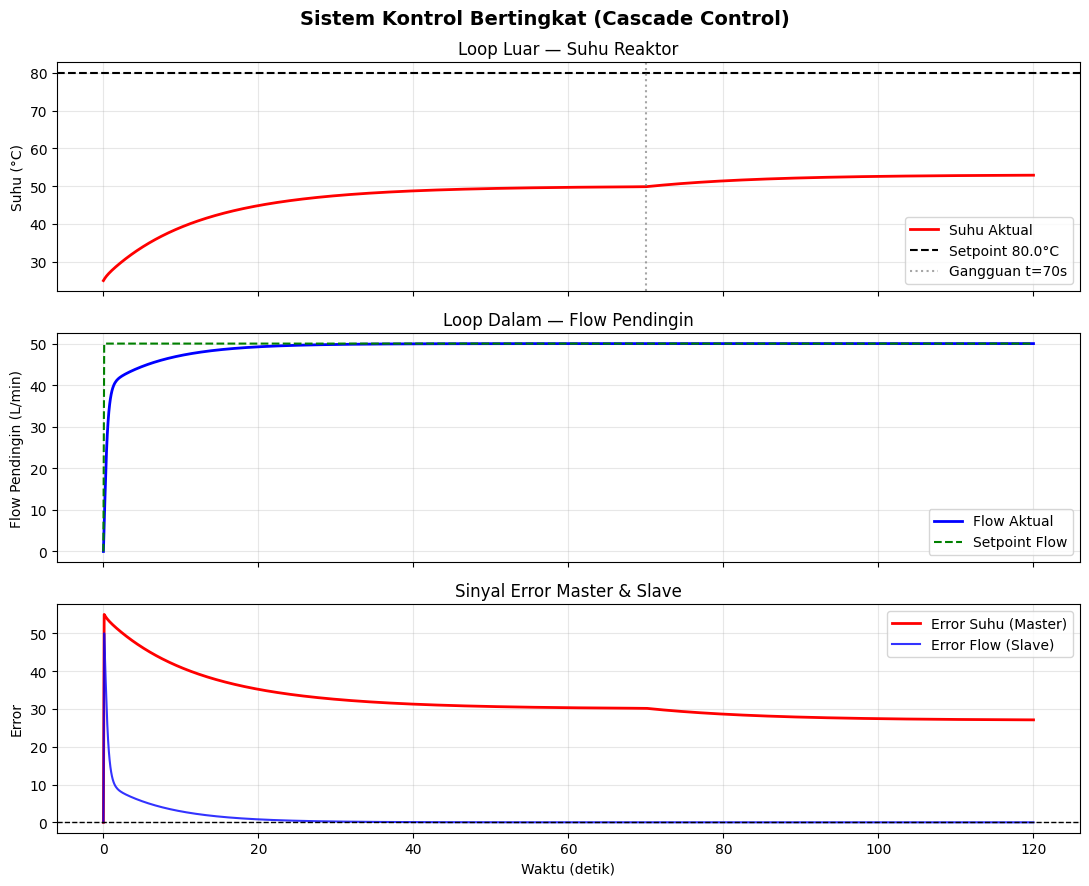


===== ANALISIS SISTEM KONTROL BERTINGKAT =====
Setpoint Suhu          : 80.0 °C
Suhu Steady State      : 52.89 °C
Error Steady State     : 27.1121 °C
Overshoot              : 0.00 °C (0.0%)
Rise Time (10%-90%)    : 0.0 detik
Sistem                 : TIDAK STABIL ✗
Disturbance Rejection  : PERLU TUNING ⚠


In [2]:
"""
SISTEM KONTROL BERTINGKAT / CASCADE CONTROL
=============================================
Loop Luar (Master) : mengontrol suhu reaktor → setpoint 80°C
Loop Dalam (Slave) : mengontrol flow pendingin
"""

import numpy as np
import matplotlib.pyplot as plt

# ─── Parameter PID Master (outer - suhu) ─────────────────────────────────────
Kp_m, Ki_m, Kd_m = 2.0, 0.05, 0.2

# ─── Parameter PID Slave (inner - flow) ──────────────────────────────────────
Kp_s, Ki_s, Kd_s = 3.0, 0.5, 0.05

# ─── Waktu ───────────────────────────────────────────────────────────────────
t  = np.linspace(0, 120, 1200)
dt = t[1] - t[0]

SP_suhu = 80.0   # setpoint suhu °C

# ─── Variabel ────────────────────────────────────────────────────────────────
suhu  = np.zeros(len(t)); suhu[0]  = 25.0
flow  = np.zeros(len(t)); flow[0]  = 0.0
err_m = np.zeros(len(t))
err_s = np.zeros(len(t))
SP_flow_arr = np.zeros(len(t))

int_m = 0.0; prev_m = 0.0
int_s = 0.0; prev_s = 0.0

# ─── Simulasi ────────────────────────────────────────────────────────────────
for i in range(1, len(t)):
    # Gangguan kecil di t=70
    dist = 3.0 if t[i] >= 70 else 0.0

    # Master loop
    err_m[i] = SP_suhu - suhu[i-1]
    int_m    = np.clip(int_m + err_m[i]*dt, -100, 100)
    u_m      = np.clip(Kp_m*err_m[i] + Ki_m*int_m + Kd_m*(err_m[i]-prev_m)/dt, 0, 50)
    prev_m   = err_m[i]
    SP_flow_arr[i] = u_m

    # Slave loop
    err_s[i] = u_m - flow[i-1]
    int_s    = np.clip(int_s + err_s[i]*dt, -200, 200)
    u_s      = np.clip(Kp_s*err_s[i] + Ki_s*int_s + Kd_s*(err_s[i]-prev_s)/dt, 0, 100)
    prev_s   = err_s[i]

    # Dinamika flow (cepat, tau=1.5s)
    flow[i] = flow[i-1] + (-flow[i-1] + u_s) / 1.5 * dt

    # Dinamika suhu (lambat, tau=15s)
    # suhu naik menuju SP, didinginkan oleh flow
    dsuhu   = (SP_suhu - suhu[i-1] - 0.6*flow[i] + dist) / 15.0
    suhu[i] = suhu[i-1] + dsuhu * dt

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle("Sistem Kontrol Bertingkat (Cascade Control)", fontsize=14, fontweight="bold")

axes[0].plot(t, suhu, "r-", label="Suhu Aktual", lw=2)
axes[0].axhline(SP_suhu, color="k", ls="--", label=f"Setpoint {SP_suhu}°C", lw=1.5)
axes[0].axvline(70, color="gray", ls=":", alpha=0.7, label="Gangguan t=70s")
axes[0].set_ylabel("Suhu (°C)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Loop Luar — Suhu Reaktor")

axes[1].plot(t, flow, "b-", label="Flow Aktual", lw=2)
axes[1].plot(t, SP_flow_arr, "g--", label="Setpoint Flow", lw=1.5)
axes[1].set_ylabel("Flow Pendingin (L/min)"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Loop Dalam — Flow Pendingin")

axes[2].plot(t, err_m, "r-", label="Error Suhu (Master)", lw=2)
axes[2].plot(t, err_s, "b-", label="Error Flow (Slave)", lw=1.5, alpha=0.8)
axes[2].axhline(0, color="k", ls="--", lw=1)
axes[2].set_ylabel("Error"); axes[2].set_xlabel("Waktu (detik)")
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title("Sinyal Error Master & Slave")

plt.tight_layout()
plt.savefig("hasil_bertingkat.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── Analisis ────────────────────────────────────────────────────────────────
ss_err    = abs(err_m[-1])
overshoot = max(0, suhu.max() - SP_suhu)

sp_range = SP_suhu - suhu[0]
idx10 = np.argmax(suhu >= suhu[0] + 0.1*sp_range)
idx90 = np.argmax(suhu >= suhu[0] + 0.9*sp_range)
rise_time = t[idx90] - t[idx10] if idx90 > idx10 else 0

print("\n===== ANALISIS SISTEM KONTROL BERTINGKAT =====")
print(f"Setpoint Suhu          : {SP_suhu} °C")
print(f"Suhu Steady State      : {suhu[-1]:.2f} °C")
print(f"Error Steady State     : {ss_err:.4f} °C")
print(f"Overshoot              : {overshoot:.2f} °C ({overshoot/SP_suhu*100:.1f}%)")
print(f"Rise Time (10%-90%)    : {rise_time:.1f} detik")
print(f"Sistem                 : {'STABIL ✓' if ss_err < 2.0 else 'TIDAK STABIL ✗'}")
print(f"Disturbance Rejection  : {'BAIK ✓' if abs(suhu[700:].mean() - SP_suhu) < 3 else 'PERLU TUNING ⚠'}")